In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LassoCV 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import seaborn as sns # for data visualization
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline  
from ucimlrepo import fetch_ucirepo 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 



  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

df_bre = pd.concat([breast_cancer_wisconsin_diagnostic.data.features, 
                breast_cancer_wisconsin_diagnostic.data.targets], axis=1) # used to glue or stack multiple DataFrames or Series together, either vertically (row-wise) or horizontally (column-wise)

# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

# NANs and Categorical reassurance

In [4]:
for columna in X.columns:
    print(f"Columna: {columna}, Tipo de dato: {X[columna].dtype}, Numero de valores nulos: {X[columna].isna().sum()}/n") 

print(f" Tipo de dato target: {y.dtypes.iloc[0]}, Numero de valores nulos target: {y.isna().sum()}")



Columna: radius1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: texture1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: perimeter1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: area1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: smoothness1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: compactness1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: concavity1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: concave_points1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: symmetry1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: fractal_dimension1, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: radius2, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: texture2, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: perimeter2, Tipo de dato: float64, Numero de valores nulos: 0/n
Columna: area2, Tipo de dato: float64, Numero de va

In [5]:
categorias = y['Diagnosis'].unique()
print(categorias)

['M' 'B']


# Descriptive statistics

In [6]:
columna = []
media = []
mediana = []
desviacion_estandar = []
moda = []


for columna in X.columns:
    media.append(X[columna].mean())
    mediana.append(X[columna].median())
    desviacion_estandar.append(X[columna].std())
    moda.append(X[columna].mode()[0])

estadisticas = pd.DataFrame({'Columna': X.columns, 'Media': media, 'Mediana': mediana, 'Desviacion_Estandar': desviacion_estandar, 'Moda': moda})
estadisticas

,Columna,Media,Mediana,Desviacion_Estandar,Moda
0,radius1,14.127292,13.370000,3.524049,12.340000
1,texture1,19.289649,18.840000,4.301036,14.930000
2,perimeter1,91.969033,86.240000,24.298981,82.610000
3,area1,654.889104,551.100000,351.914129,512.200000
4,smoothness1,0.096360,0.095870,0.014064,0.100700
5,compactness1,0.104341,0.092630,0.052813,0.114700
6,concavity1,0.088799,0.061540,0.079720,0.000000
7,concave_points1,0.048919,0.033500,0.038803,0.000000
8,symmetry1,0.181162,0.179200,0.027414,0.160100
9,fractal_dimension1,0.062798,0.061540,0.007060,0.056670


### Distribucion de poblacion para los radios1,2,3 acorde a maligno y benigno

In [7]:
radio_benigno1 = df_bre[df_bre['Diagnosis'] == 'B']['radius1']
radio_maligno1 = df_bre[df_bre['Diagnosis'] == 'M']['radius1']

radio_benigno2 = df_bre[df_bre['Diagnosis'] == 'B']['radius2']
radio_maligno2 = df_bre[df_bre['Diagnosis'] == 'M']['radius2']

radio_benigno3 = df_bre[df_bre['Diagnosis'] == 'B']['radius3']
radio_maligno3 = df_bre[df_bre['Diagnosis'] == 'M']['radius3']

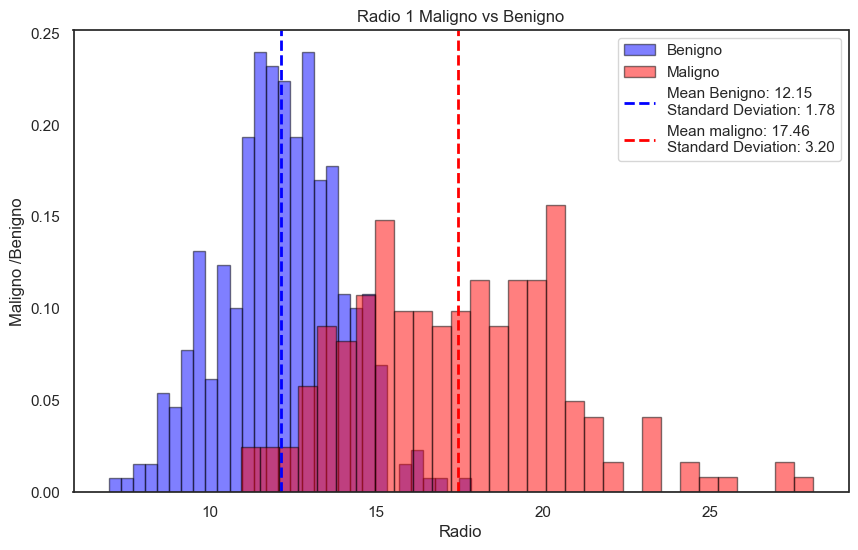

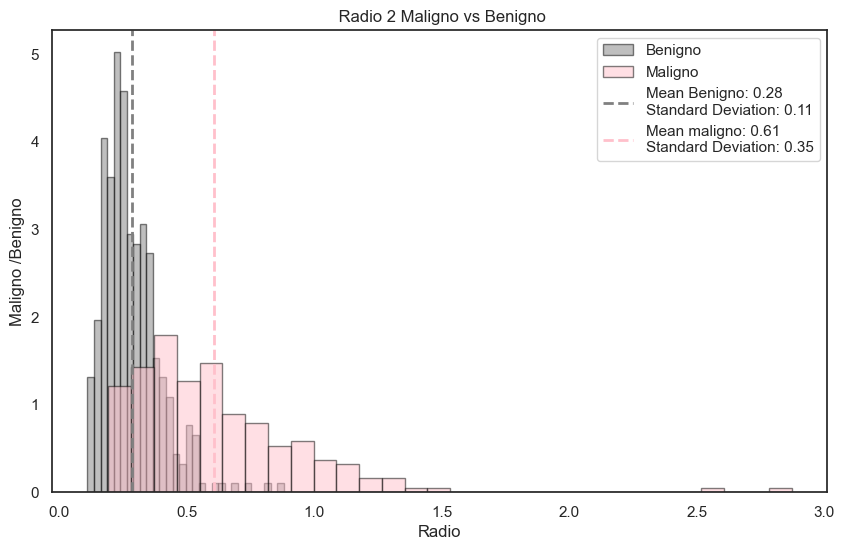

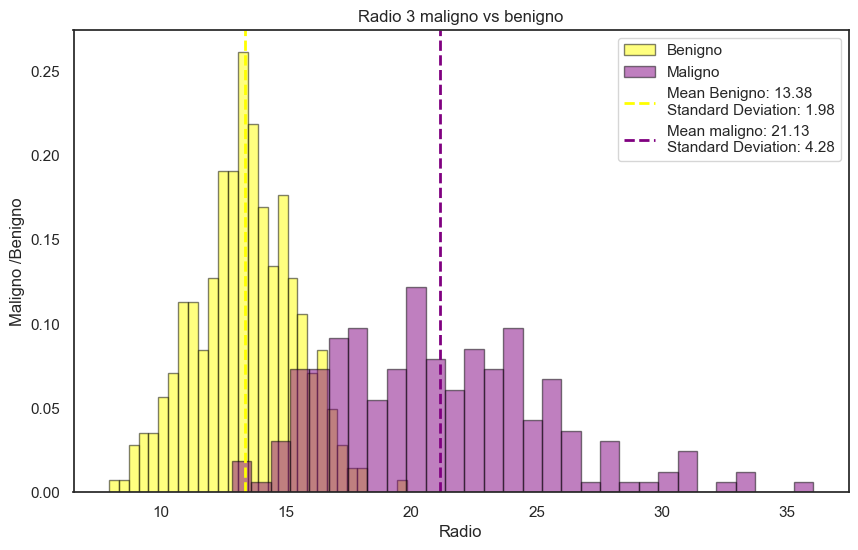

In [11]:
"""
RADIUS 1
"""

plt.figure(figsize=(10, 6))

# Create histograms using MEDV_scaled
plt.hist(radio_benigno1, bins=30, alpha=0.5, color='blue', density=True, label='Benigno', edgecolor='black')
plt.hist(radio_maligno1, bins=30, alpha=0.5, color='red', density=True, label='Maligno', edgecolor='black')

# Add vertical lines showing the mean of MEDV_scaled for each class
plt.axvline(radio_benigno1.mean(), color='blue', linestyle='dashed', linewidth=2, 
            label=f'Mean Benigno: {radio_benigno1.mean():.2f}\nStandard Deviation: {radio_benigno1.std():.2f}')  # value = indicates format specification / .2 = shows exactly 2 decimals / f = indicates float
plt.axvline(radio_maligno1.mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Mean maligno: {radio_maligno1.mean():.2f}\nStandard Deviation: {radio_maligno1.std():.2f}')

# Add labels and legend
plt.xlabel('Radio')
plt.ylabel('Maligno /Benigno')
plt.legend()
plt.title('Radio 1 Maligno vs Benigno')
plt.show()

"""
RADIUS 2
"""


plt.figure(figsize=(10, 6))

# Create histograms using MEDV_scaled
plt.hist(radio_benigno2, bins=30, alpha=0.5, color='gray', density=True, label='Benigno', edgecolor='black')
plt.hist(radio_maligno2, bins=30, alpha=0.5, color='pink', density=True, label='Maligno', edgecolor='black')

# Add vertical lines showing the mean of MEDV_scaled for each class
plt.axvline(radio_benigno2.mean(), color='gray', linestyle='dashed', linewidth=2, 
            label=f'Mean Benigno: {radio_benigno2.mean():.2f}\nStandard Deviation: {radio_benigno2.std():.2f}')  # value = indicates format specification / .2 = shows exactly 2 decimals / f = indicates float
plt.axvline(radio_maligno2.mean(), color='pink', linestyle='dashed', linewidth=2,
            label=f'Mean maligno: {radio_maligno2.mean():.2f}\nStandard Deviation: {radio_maligno2.std():.2f}')

# Add labels and legend
plt.xlabel('Radio')
plt.ylabel('Maligno /Benigno')
plt.legend()
plt.title(' Radio 2 Maligno vs Benigno')
plt.show()



"""
RADIUS 3
"""


plt.figure(figsize=(10, 6))

# Create histograms using MEDV_scaled
plt.hist(radio_benigno3, bins=30, alpha=0.5, color='yellow', density=True, label='Benigno', edgecolor='black')
plt.hist(radio_maligno3, bins=30, alpha=0.5, color='purple', density=True, label='Maligno', edgecolor='black')

# Add vertical lines showing the mean of MEDV_scaled for each class
plt.axvline(radio_benigno3.mean(), color='yellow', linestyle='dashed', linewidth=2, 
            label=f'Mean Benigno: {radio_benigno3.mean():.2f}\nStandard Deviation: {radio_benigno3.std():.2f}')  # value = indicates format specification / .2 = shows exactly 2 decimals / f = indicates float
plt.axvline(radio_maligno3.mean(), color='purple', linestyle='dashed', linewidth=2,
            label=f'Mean maligno: {radio_maligno3.mean():.2f}\nStandard Deviation: {radio_maligno3.std():.2f}')

# Add labels and legend
plt.xlabel('Radio')
plt.ylabel('Maligno /Benigno')
plt.legend()
plt.title('Radio 3 maligno vs benigno')
plt.show()

# HEATMAP


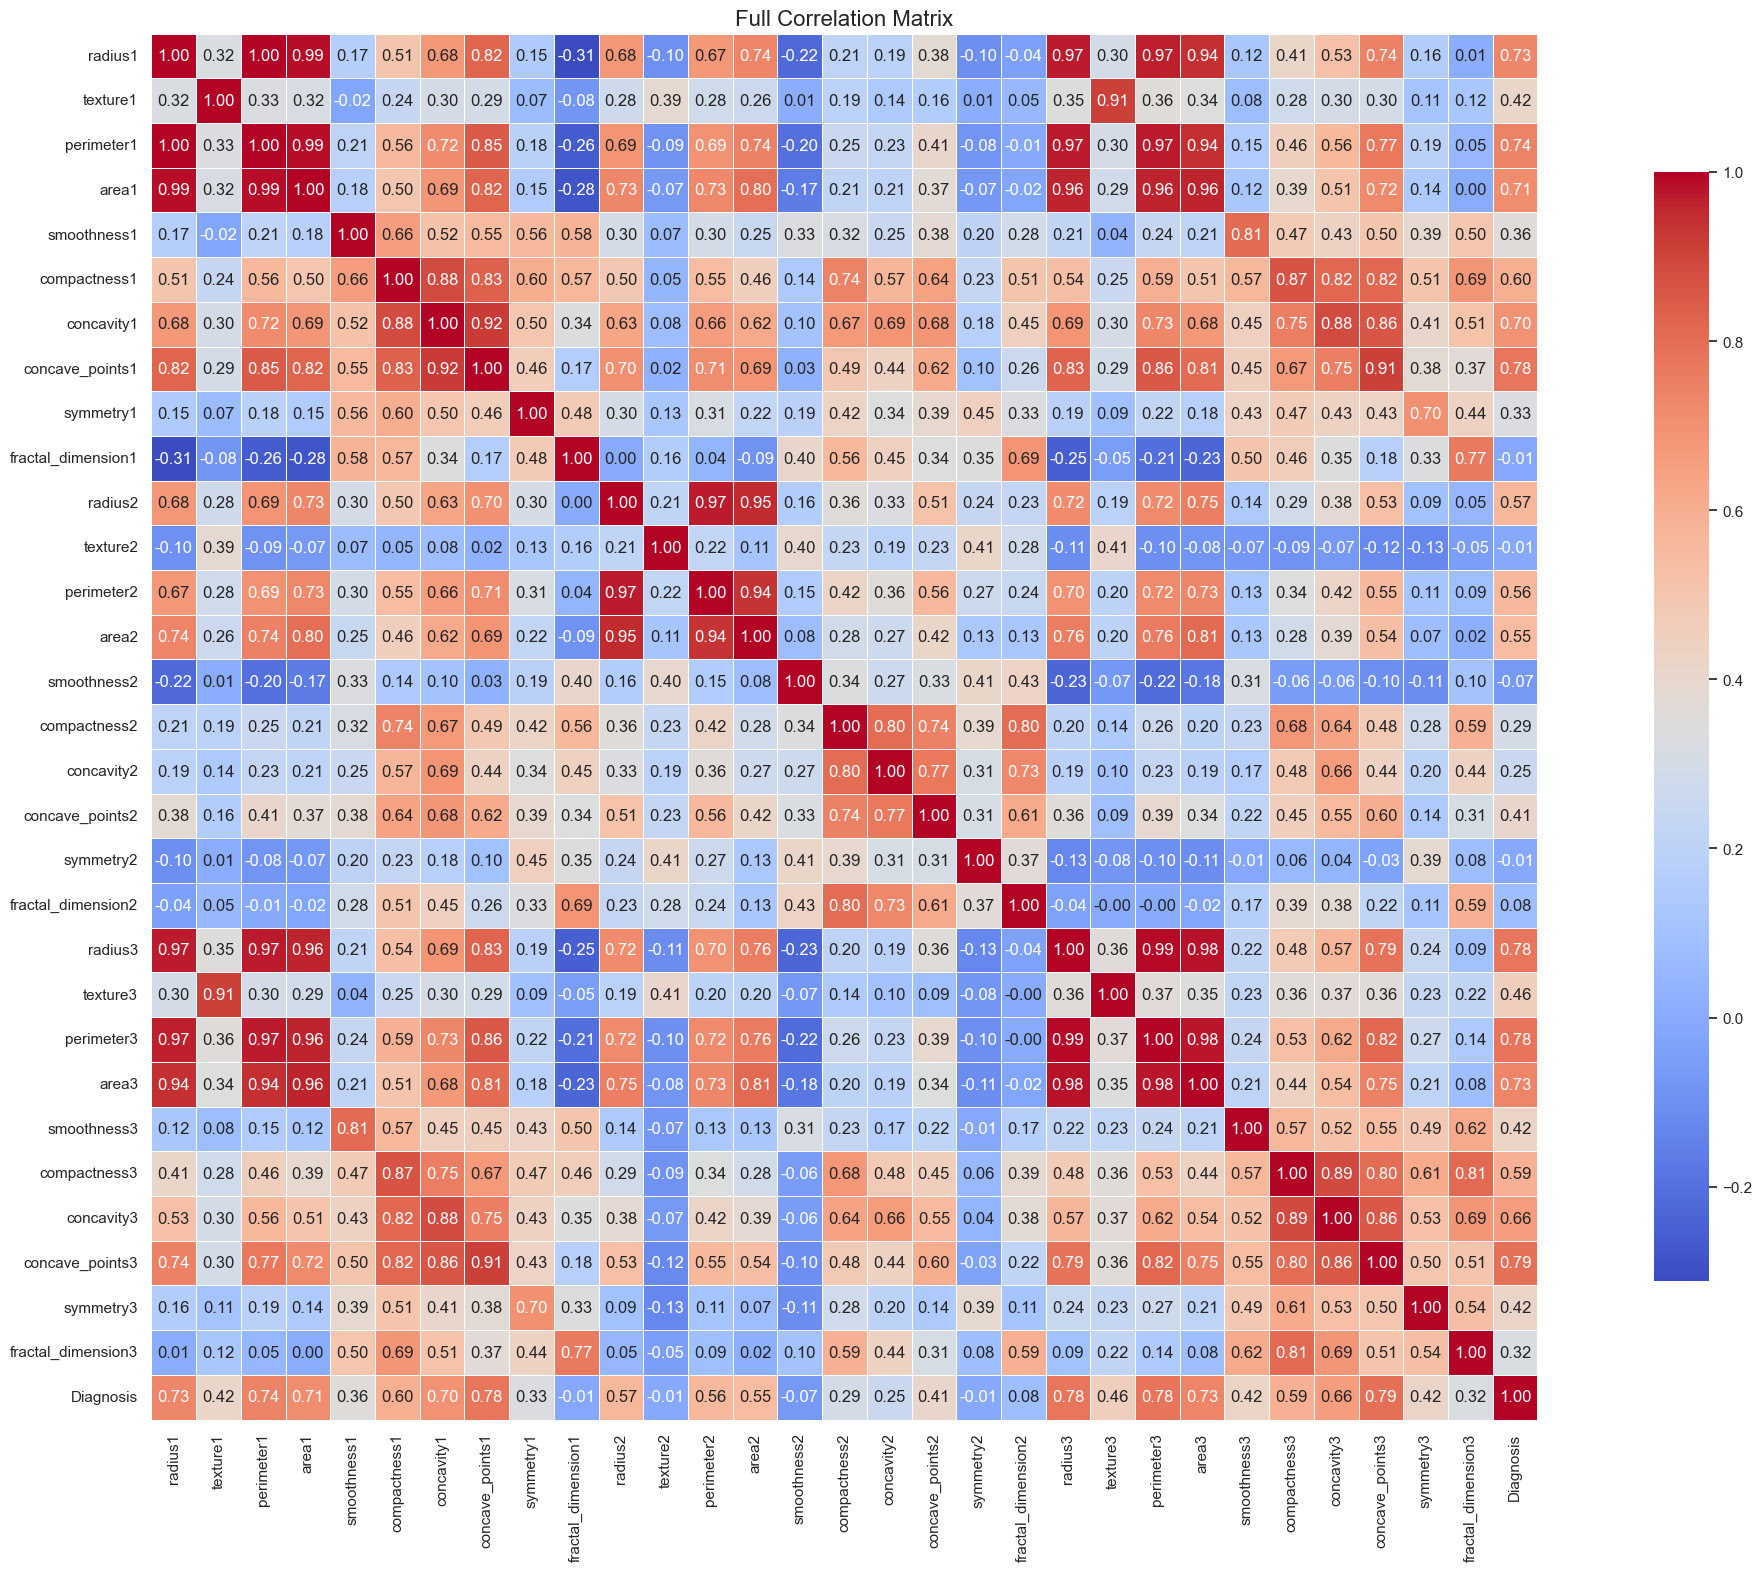

In [9]:
df_bre['Diagnosis'] = df_bre['Diagnosis'].map({'M': 1.0, 'B': 0.0})


# Calculate the correlation
corr = df_bre.corr()

# Create a mask of zeros (np.zeros_like)
# Since they are all zeros (False), all cells will be displayed
mask = np.zeros_like(corr, dtype=bool)

# Configure the plot aesthetics
plt.figure(figsize=(30, 18))
sns.set_theme(style="white")

# Draw the full heatmap
sns.heatmap(
    corr, 
    mask=mask,               # Apply the zero mask (shows all)
    cmap='coolwarm',         # The color map you chose
    square=True,             # Square cells
    linewidths=.5,           # Lines between cells
    annot=True,              # Show numeric values
    fmt=".2f",               # Format with 2 decimal places
    cbar_kws={"shrink": .8}  # Adjust size of the side bar
)

plt.title('Full Correlation Matrix', fontsize=16)
plt.show()

# MODELS TO REDUCE DIMENSIONALITY

--- Resultados: Regresión Logística ---
              precision    recall  f1-score   support

           B       0.98      0.98      0.98       108
           M       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



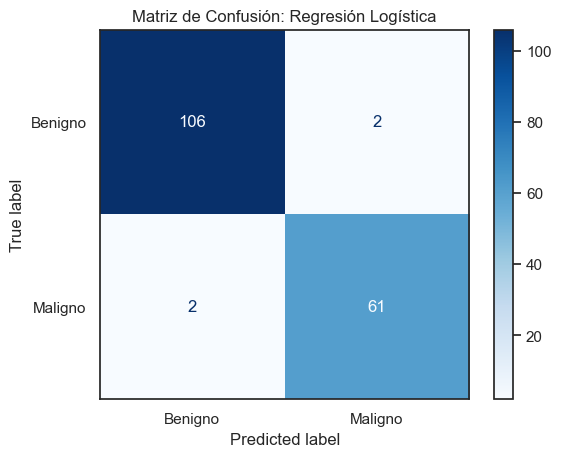


--- Resultados: Random Forest ---
              precision    recall  f1-score   support

           B       0.96      0.99      0.98       108
           M       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



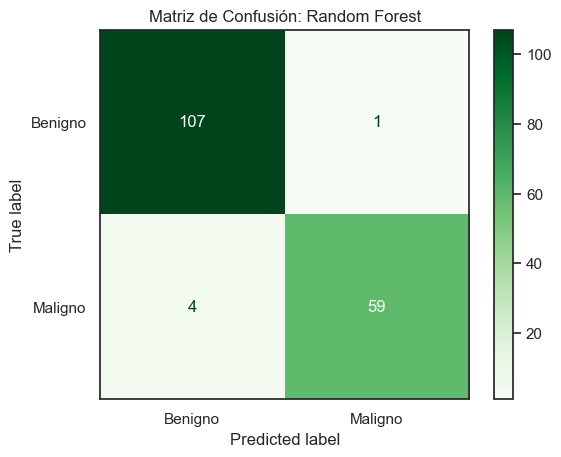

Dimensiones originales: (569, 30)
Dimensiones actuales: (398, 30)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 1. REGRESIÓN LOGÍSTICA ---
print("--- Resultados: Regresión Logística ---")
modelo_log = LogisticRegression(max_iter=10000)
# Entrenamos usando .values.ravel() para evitar el warning
modelo_log.fit(x_train, y_train.values.ravel()) 
predicciones_log = modelo_log.predict(x_test)

# Reporte de métricas Logística
print(classification_report(y_test, predicciones_log))

# Matriz de Confusión Logística
cm_log = confusion_matrix(y_test, predicciones_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Benigno', 'Maligno'])
disp_log.plot(cmap='Blues')
plt.title('Matriz de Confusión: Regresión Logística')
plt.show()




# --- 2. RANDOM FOREST ---
print("\n--- Resultados: Random Forest ---")
modelo_rf = RandomForestClassifier(n_estimators=1000, random_state=42)
# Entrenamos usando .values.ravel()
modelo_rf.fit(x_train, y_train.values.ravel()) 
predicciones_rf = modelo_rf.predict(x_test)

# Reporte de métricas Random Forest
print(classification_report(y_test, predicciones_rf))

# Matriz de Confusión Random Forest
cm_rf = confusion_matrix(y_test, predicciones_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Benigno', 'Maligno'])
disp_rf.plot(cmap='Greens') # Cambié el color a verde para diferenciarlo
plt.title('Matriz de Confusión: Random Forest')
plt.show()

# Ver dimensiones (filas, columnas)
print(f"Dimensiones originales: {X.shape}")

# Si eliminaste columnas o usaste un selector:
print(f"Dimensiones actuales: {x_train.shape}")